In [1]:
%load_ext autoreload
%autoreload 1

import torch
import glob
import math
import PIL
import torchvision.transforms as transforms

from mylib.plot import plot_imgs

In [2]:
images_path = sorted(glob.glob(f"/home/mattia/Desktop/datasets/mydataset/data/vienna_state_opera/frames/*/*"))[:5]

# load images
images = [PIL.Image.open(img_path) for img_path in images_path]
images_th = [transforms.ToTensor()(img).unsqueeze(0) for img in images]

# # resize to 518 long edge
min_size = int(images_th[0].shape[3] / (images_th[0].shape[2]/518))
resize_transform = transforms.Resize(min_size)
images_th = [resize_transform(img_th) for img_th in images_th]

# print sizes
for i, img_th in enumerate(images_th):
    print(f"Image {i}: {img_th.shape}")  # (1, 3, H, W)

Image 0: torch.Size([1, 3, 517, 291])
Image 1: torch.Size([1, 3, 517, 291])
Image 2: torch.Size([1, 3, 517, 291])
Image 3: torch.Size([1, 3, 517, 291])
Image 4: torch.Size([1, 3, 517, 291])


In [3]:
from extractors.canny import CannyEdgeDetector
canny_extractor = CannyEdgeDetector()

from extractors.TEED.teed_wrapper import TeedWrapper
teed_extractor = TeedWrapper(device="cuda")

CannyEdgeDetector initialized with low_threshold=0.2, high_threshold=0.25, hysteresis=True, kernel_size=7, sigma=2.0, device=cuda



In [12]:
k = 0
img_canny = canny_extractor(images_th[k]).squeeze().cpu()
img_teed = teed_extractor(images_th[k], low_threshold=0.8, high_threshold=1.0).squeeze().cpu()

# print non vers values
print(f"Canny: {torch.nonzero(img_canny).sum().item():,}")
print(f"TEED: {torch.nonzero(img_teed).sum().item():,}")

Canny: 3,810,695
TEED: 4,253,729


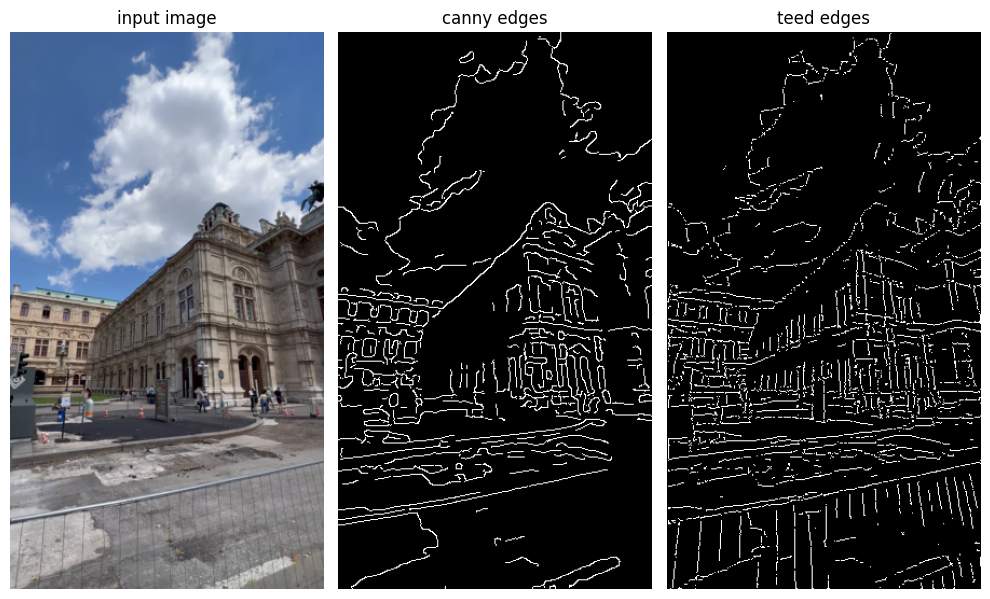

In [13]:
plot_imgs([images_th[k].squeeze().permute(1, 2, 0).cpu().numpy(), img_canny, img_teed], titles=["input image", "canny edges", "teed edges"], figsize=(10, 10), cmap=[None, "gray", "gray"])